In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install wfdb -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 87.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incom

In [ ]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ID'leri bulalim

In [ ]:
import os
import glob

dataset_path = '/content/drive/MyDrive/Colab Notebooks/MITBIH/mit-bih-arrhythmia-database-1.0.0'
hea_files = glob.glob(os.path.join(dataset_path, '*.hea'))

patient_ids = []

for file_path in hea_files:
    file_name = os.path.basename(file_path)

    patient_id = file_name.split('.')[0]

    patient_ids.append(patient_id)

patient_ids.sort()

print(f"Toplam {len(patient_ids)} adet hasta kaydı (ID) bulundu.")
print("Patient ID Listesi:", patient_ids)

Toplam 48 adet hasta kaydı (ID) bulundu.
Patient ID Listesi: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [ ]:
from scipy.signal import find_peaks

Peak finds

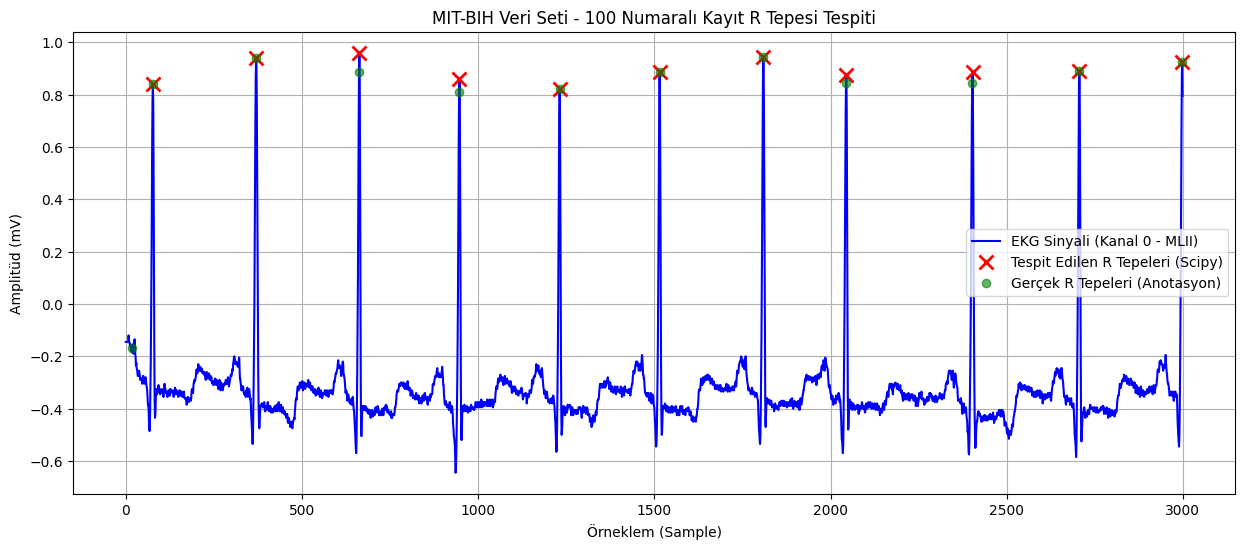

In [ ]:
base_path = '/content/drive/MyDrive/Colab Notebooks/MITBIH/mit-bih-arrhythmia-database-1.0.0/100'

record = wfdb.rdrecord(base_path, sampto=3000)
signal = record.p_signal[:, 0]  # Genellikle 0. kanal MLII (Modifiye Kurşun II) derivasyonudur
fs = record.fs                  # Örnekleme frekansı (MIT-BIH için genellikle 360 Hz'dir)

# distance: İki R tepesi arasındaki minimum mesafe (360 Hz'de 150 örnek, yaklaşık 0.4 saniye eder)
detected_peaks, _ = find_peaks(signal, height=0.5, distance=150)

# 3. VERİ SETİNİN KENDİ ANOTASYONLARINI OKUMA (Gerçek (Ground Truth) R Tepeleri)
# 'atr' uzantısı, aritmi açıklamalarını ve gerçek R tepesi konumlarını içerir
annotation = wfdb.rdann(base_path, 'atr', sampto=3000)
true_peaks = annotation.sample

# 4. GÖRSELLEŞTİRME
plt.figure(figsize=(15, 6))
plt.plot(signal, label='EKG Sinyali (Kanal 0 - MLII)', color='blue')

# Algoritmanın bulduğu tepeleri Kırmızı 'x' ile işaretle
plt.plot(detected_peaks, signal[detected_peaks], "x", color='red', markersize=10, markeredgewidth=2, label='Tespit Edilen R Tepeleri (Scipy)')

# Gerçek (uzman) işaretlemelerini Yeşil yuvarlaklarla göster
plt.plot(true_peaks, signal[true_peaks], "o", color='green', markersize=6, alpha=0.6, label='Gerçek R Tepeleri (Anotasyon)')

plt.title("MIT-BIH Veri Seti - 100 Numaralı Kayıt R Tepesi Tespiti")
plt.xlabel("Örneklem (Sample)")
plt.ylabel("Amplitüd (mV)")
plt.legend()
plt.grid(True)
plt.show()

NORMALIZASYON

In [ ]:
normalized_data = {}

In [ ]:
dataset_path = '/content/drive/MyDrive/Colab Notebooks/MITBIH/mit-bih-arrhythmia-database-1.0.0'


for pid in patient_ids:
  record_path = os.path.join(dataset_path, pid)

  record = wfdb.rdrecord(record_path)

  #veri setinde hastanın elektrotlarının bağlandığı yerlere göre değişen 2 kanal olduğu için birinci kanalı tercihi yapıyoruz.
  signal = record.p_signal[:, 0]
  signal = np.nan_to_num(signal)

  mean_val = np.mean(signal)
  std_val = np.std(signal)

  # z = (x−μ) / σ​
  normalized_signal = (signal - mean_val) / (std_val)
  normalized_data[pid] = normalized_signal

print(f"Toplam {len(normalized_data)} hastanın verisi okundu ve normalize edildi.")

Toplam 48 hastanın verisi okundu ve normalize edildi.


In [ ]:
# Örnek olarak bir kontrol yapalım:
sample_id = patient_ids[0]
print(f"\n--- ÖRNEK KONTROL ({sample_id} Numaralı Kayıt) ---")
print(f"Orijinal Uzunluk: {len(normalized_data[sample_id])} örneklem")
print(f"Yeni Ortalama: {np.mean(normalized_data[sample_id]):.4f} (0'a çok yakın olmalı)")
print(f"Yeni Standart Sapma: {np.std(normalized_data[sample_id]):.4f} (1'e eşit olmalı)")


--- ÖRNEK KONTROL (100 Numaralı Kayıt) ---
Orijinal Uzunluk: 650000 örneklem
Yeni Ortalama: -0.0000 (0'a çok yakın olmalı)
Yeni Standart Sapma: 1.0000 (1'e eşit olmalı)


In [ ]:
# He J, Sun L, Rong J, Wang H, Zhang Y. A pyramid-like model for heartbeat classification from ECG recordings.
LEFT_WINDOW = 90
RIGHT_WINDOW = 144

dataset_path = '/content/drive/MyDrive/Colab Notebooks/MITBIH/mit-bih-arrhythmia-database-1.0.0'

X_data = []
y_labels = []


for pid in patient_ids:
    signal = normalized_data[pid]
    record_path = os.path.join(dataset_path, pid)

    # Gerçek R tepesi konumlarını ve bu atışların etiketlerini okuma
    annotation = wfdb.rdann(record_path, 'atr')
    peaks = annotation.sample
    symbols = annotation.symbol

    for i in range(len(peaks)):
        r_peak = peaks[i]
        label = symbols[i]

        if (r_peak - LEFT_WINDOW < 0) or (r_peak + RIGHT_WINDOW >= len(signal)):
            continue

        segment = signal[r_peak - LEFT_WINDOW : r_peak + RIGHT_WINDOW]
        X_data.append(segment)
        y_labels.append(label)


X_data = np.array(X_data)
y_labels = np.array(y_labels)

print(f"Toplam Çıkarılan Kalp Atışı Sayısı: {len(X_data)}")
print(f"X_data matrisinin boyutu (Shape): {X_data.shape}")

Toplam Çıkarılan Kalp Atışı Sayısı: 112565
X_data matrisinin boyutu (Shape): (112565, 234)


5 ana classa boluyoruz

In [ ]:
import numpy as np

# AAMI Standardına göre sembol eşleştirme sözlüğü
aami_mapping = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,  # Sınıf 0: Normal
    'A': 1, 'a': 1, 'J': 1, 'S': 1,          # Sınıf 1: Supraventriküler (SVEB)
    'V': 2, 'E': 2,                          # Sınıf 2: Ventriküler (VEB)
    'F': 3,                                  # Sınıf 3: Fusion
    '/': 4, 'f': 4, 'Q': 4                   # Sınıf 4: Unknown / Unclassifiable
}

X_filtered = []
y_filtered = []

for i in range(len(y_labels)):
    symbol = y_labels[i]
    if symbol in aami_mapping:
        X_filtered.append(X_data[i])
        y_filtered.append(aami_mapping[symbol])

X_final = np.array(X_filtered)
y_final = np.array(y_filtered)

print(f"Kullanılabilir Toplam Atış Sayısı: {len(X_final)}")

unique, counts = np.unique(y_final, return_counts=True)
sinif_isimleri = ['0 (Normal)', '1 (SVEB)', '2 (VEB)', '3 (Fusion)', '4 (Unknown)']

for i in range(len(unique)):
    print(f"{sinif_isimleri[i]} sınıfı: {counts[i]} adet")

Kullanılabilir Toplam Atış Sayısı: 109454
0 (Normal) sınıfı: 90595 adet
1 (SVEB) sınıfı: 2781 adet
2 (VEB) sınıfı: 7235 adet
3 (Fusion) sınıfı: 802 adet
4 (Unknown) sınıfı: 8041 adet


Unknownlari atalim

In [ ]:
mask = (y_final != 4)

X_cleaned = X_final[mask]
y_cleaned = y_final[mask]

unique_new, counts_new = np.unique(y_cleaned, return_counts=True)


Class weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

unique_classes = np.unique(y_cleaned)

weights = compute_class_weight(class_weight='balanced',
                               classes=unique_classes,
                               y=y_cleaned)

class_weights_dict = dict(zip(unique_classes, weights))

print("--- CLASS WEIGHTS (SINIF AĞIRLIKLARI) ---")
for cls, weight in class_weights_dict.items():
    print(f"Sınıf {cls}: {weight:.4f}")

--- CLASS WEIGHTS (SINIF AĞIRLIKLARI) ---
Sınıf 0: 0.2799
Sınıf 1: 9.1166
Sınıf 2: 3.5043
Sınıf 3: 31.6125


CNN Definition

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

X_cnn = np.expand_dims(X_cleaned, axis=-1)

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_cleaned, test_size=0.2, random_state=42, stratify=y_cleaned
)

model = Sequential([
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout!
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\n--- MODEL ÖZETİ ---")
model.summary()


--- MODEL ÖZETİ ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 230, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 230, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 115, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 111, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 111, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 55, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 51, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 51, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,724 (1.77 MB)

 Trainable params: 462,276 (1.76 MB)

 Non-trainable params: 448 (1.75 KB)

CNN train

Epoch 1/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8925 - loss: 0.3156 - val_accuracy: 0.9188 - val_loss: 0.2667
Epoch 2/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9032 - loss: 0.2671 - val_accuracy: 0.8843 - val_loss: 0.3846
Epoch 3/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9150 - loss: 0.2276 - val_accuracy: 0.9492 - val_loss: 0.2196
Epoch 4/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9162 - loss: 0.2305 - val_accuracy: 0.9667 - val_loss: 0.1290
Epoch 5/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9170 - loss: 0.2284 - val_accuracy: 0.9286 - val_loss: 0.2293
Epoch 6/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9266 - loss: 0.1977 - val_accuracy: 0.8944 - val_loss: 0.3990
Epoch 7/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9272 - loss: 0.2071 - val_accuracy: 0.9550 - val_loss: 0.1727
Epoch 8/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9237 - loss: 0.2237 - 

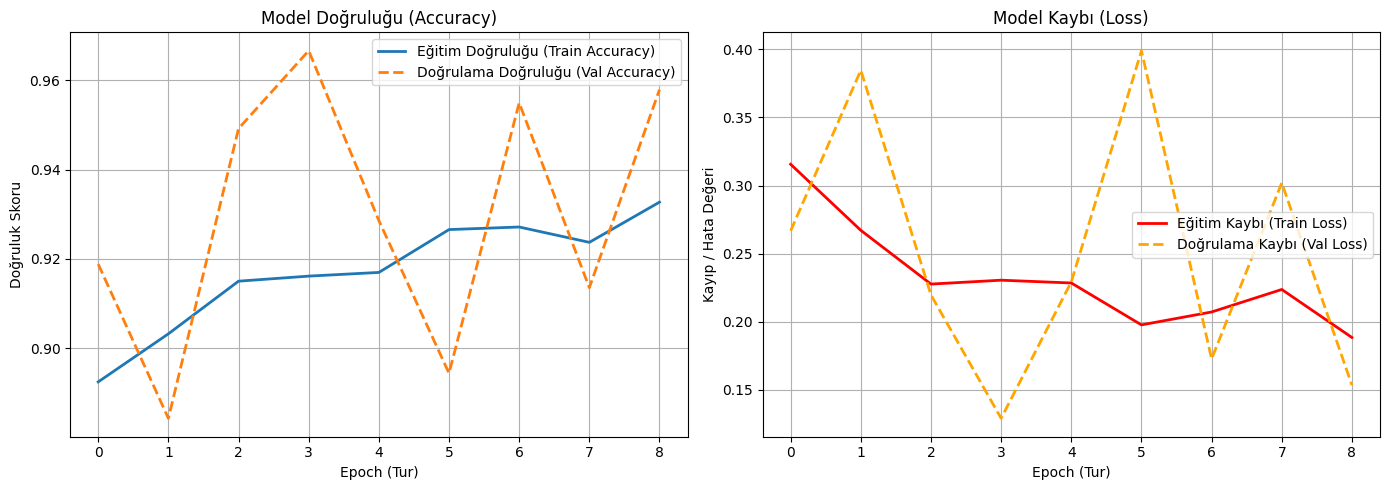

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

print("\n--- EĞİTİM TAMAMLANDI ---")

# 3. EĞİTİM SONUÇLARINI GÖRSELLEŞTİRME
plt.figure(figsize=(14, 5))

# Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu (Train Accuracy)', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu (Val Accuracy)', linewidth=2, linestyle='--')
plt.title('Model Doğruluğu (Accuracy)')
plt.xlabel('Epoch (Tur)')
plt.ylabel('Doğruluk Skoru')
plt.legend()
plt.grid(True)

# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı (Train Loss)', linewidth=2, color='red')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Val Loss)', linewidth=2, linestyle='--', color='orange')
plt.title('Model Kaybı (Loss)')
plt.xlabel('Epoch (Tur)')
plt.ylabel('Kayıp / Hata Değeri')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


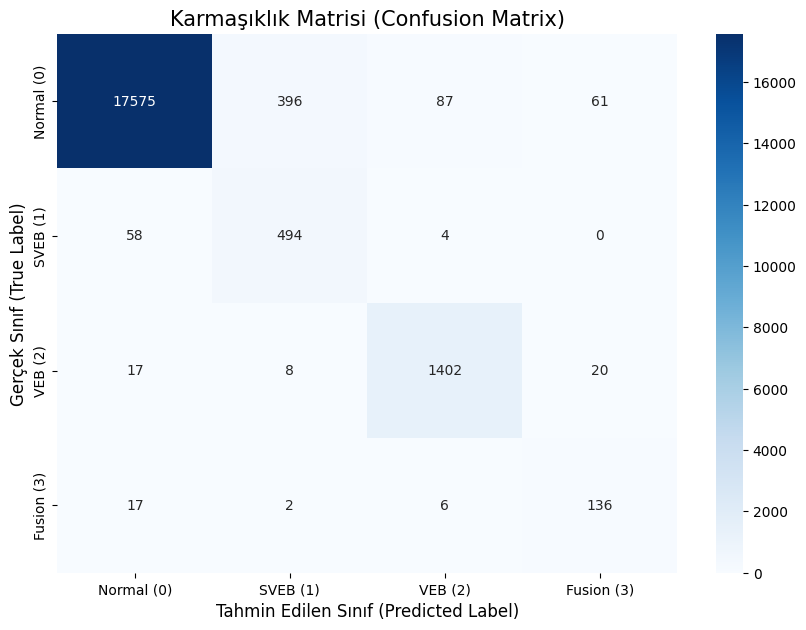


             SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

  Normal (0)       0.99      0.97      0.98     18119
    SVEB (1)       0.55      0.89      0.68       556
     VEB (2)       0.94      0.97      0.95      1447
  Fusion (3)       0.63      0.84      0.72       161

    accuracy                           0.97     20283
   macro avg       0.78      0.92      0.83     20283
weighted avg       0.98      0.97      0.97     20283



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

class_names = ['Normal (0)', 'SVEB (1)', 'VEB (2)', 'Fusion (3)']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Karmaşıklık Matrisi (Confusion Matrix)', fontsize=15)
plt.ylabel('Gerçek Sınıf (True Label)', fontsize=12)
plt.xlabel('Tahmin Edilen Sınıf (Predicted Label)', fontsize=12)
plt.show()

# 3. SINIFLANDIRMA RAPORU (CLASSIFICATION REPORT)
print("\n" + "="*50)
print("             SINIFLANDIRMA RAPORU")
print("="*50)
print(classification_report(y_test, y_pred, target_names=class_names))

SAVE CNN

In [ ]:
# Modelin kaydedileceği yol (Drive'ındaki klasör)
# .keras uzantısı Keras'ın en güncel ve önerilen kayıt formatıdır
model_save_path = '/content/drive/MyDrive/Colab Notebooks/MITBIH/best_ecg_1dcnn_model.keras'

# Modeli kaydet
model.save(model_save_path)

print(f"Model başarıyla kaydedildi!\nKayıt Yolu: {model_save_path}")

Model başarıyla kaydedildi!
Kayıt Yolu: /content/drive/MyDrive/Colab Notebooks/MITBIH/best_ecg_1dcnn_model.keras


In [ ]:
from tensorflow.keras.models import load_model

# Modeli Drive'dan geri yükle
loaded_model = load_model('/content/drive/MyDrive/Colab Notebooks/MITBIH/best_ecg_1dcnn_model.keras')

# Hemen test etmek istersen
# predictions = loaded_model.predict(X_test)

LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

# 1. LSTM MODEL MİMARİSİNİ KURMA
lstm_model = Sequential([
    # İlk LSTM Katmanı (Zaman serisindeki ardışık özellikleri yakalar)
    # return_sequences=True: Bir sonraki LSTM katmanına veriyi yine bir dizi olarak aktarmak için gereklidir.
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    Dropout(0.3),

    # İkinci LSTM Katmanı (Daha derin bağlamları öğrenir)
    LSTM(32),
    BatchNormalization(),
    Dropout(0.3),

    # Sınıflandırma Katmanları
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Çıktı Katmanı (4 Sınıf olduğu için 4 nöron ve Softmax)
    Dense(4, activation='softmax')
])

# 2. MODELİ DERLEME
lstm_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print("\n--- LSTM MODEL ÖZETİ ---")
lstm_model.summary()

# 3. EĞİTİMİ BAŞLATMA (Early Stopping ve Class Weights kullanarak)
from tensorflow.keras.callbacks import EarlyStopping

early_stop_lstm = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nLSTM Eğitimi başlıyor... Lütfen bekleyin.")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict, # Sınıf dengesizliğini çözmek için yine ekliyoruz
    callbacks=[early_stop_lstm]
)


--- LSTM MODEL ÖZETİ ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 234, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 234, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 234, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,068 (125.27 KB)

 Trainable params: 31,876 (124.52 KB)

 Non-trainable params: 192 (768.00 B)


LSTM Eğitimi başlıyor... Lütfen bekleyin.
Epoch 1/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.3921 - loss: 1.2465 - val_accuracy: 0.3753 - val_loss: 1.4240
Epoch 2/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.5013 - loss: 1.0867 - val_accuracy: 0.6362 - val_loss: 1.0053
Epoch 3/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.5619 - loss: 1.0047 - val_accuracy: 0.7426 - val_loss: 0.9131
Epoch 4/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.6465 - loss: 0.9083 - val_accuracy: 0.7249 - val_loss: 0.8945
Epoch 5/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.6844 - loss: 0.8031 - val_accuracy: 0.7358 - val_loss: 0.8132
Epoch 6/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.7022 - loss: 0.7613 - val_accuracy: 0.8047 - val_loss: 0.7539
Epoch 7/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - accuracy: 0.7329 - loss: 0.7273 - val_accuracy: 0.8433 - val_loss: 0.6322
Epoch 8/30
1268/1268 ━━━━━━━━━━━━

Test verisi üzerinden tahminler yapılıyor...
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step


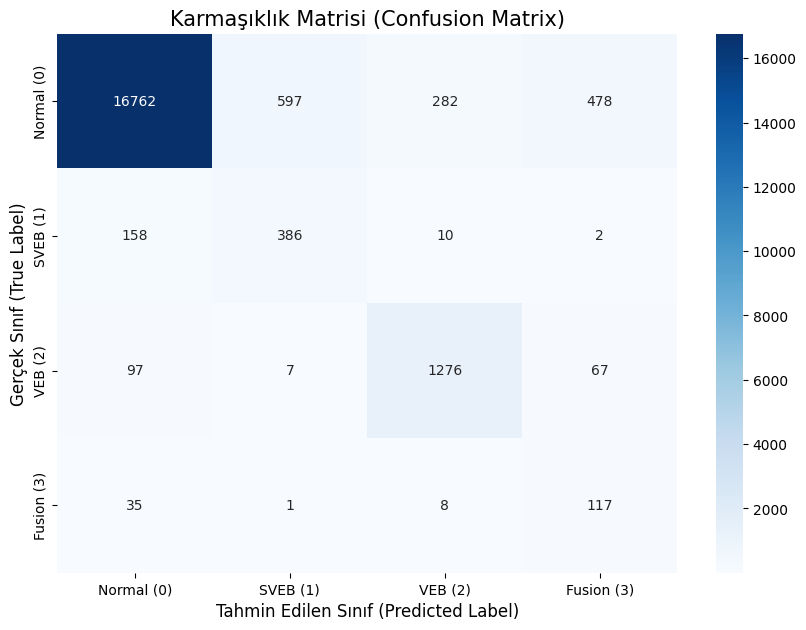


             SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

  Normal (0)       0.98      0.93      0.95     18119
    SVEB (1)       0.39      0.69      0.50       556
     VEB (2)       0.81      0.88      0.84      1447
  Fusion (3)       0.18      0.73      0.28       161

    accuracy                           0.91     20283
   macro avg       0.59      0.81      0.65     20283
weighted avg       0.95      0.91      0.93     20283



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print("Test verisi üzerinden tahminler yapılıyor...")
# 1. MODELİN TAHMİNLERİNİ ALMA
# Model bize olasılıklar (Örn: [0.1, 0.05, 0.8, 0.05]) döndürür.
y_pred_probs = lstm_model.predict(X_test)
# En yüksek olasılığa sahip sınıfı (indeksi) seçiyoruz
y_pred = np.argmax(y_pred_probs, axis=1)

# Sınıf isimleri
class_names = ['Normal (0)', 'SVEB (1)', 'VEB (2)', 'Fusion (3)']

# 2. KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX) ÇİZDİRME
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
# Heatmap ile daha görsel ve anlaşılır bir matris çizdiriyoruz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Karmaşıklık Matrisi (Confusion Matrix)', fontsize=15)
plt.ylabel('Gerçek Sınıf (True Label)', fontsize=12)
plt.xlabel('Tahmin Edilen Sınıf (Predicted Label)', fontsize=12)
plt.show()

# 3. SINIFLANDIRMA RAPORU (CLASSIFICATION REPORT)
print("\n" + "="*50)
print("             SINIFLANDIRMA RAPORU")
print("="*50)
print(classification_report(y_test, y_pred, target_names=class_names))

XGB

XGBoost eğitimi başlıyor... (Derin öğrenmeden daha hızlı bitecektir)
--- EĞİTİM TAMAMLANDI ---

Test verisi üzerinden tahminler yapılıyor...
       XGBOOST SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

  Normal (0)       0.99      0.99      0.99     18119
    SVEB (1)       0.86      0.83      0.85       556
     VEB (2)       0.96      0.96      0.96      1447
  Fusion (3)       0.85      0.76      0.81       161

    accuracy                           0.98     20283
   macro avg       0.92      0.89      0.90     20283
weighted avg       0.98      0.98      0.98     20283



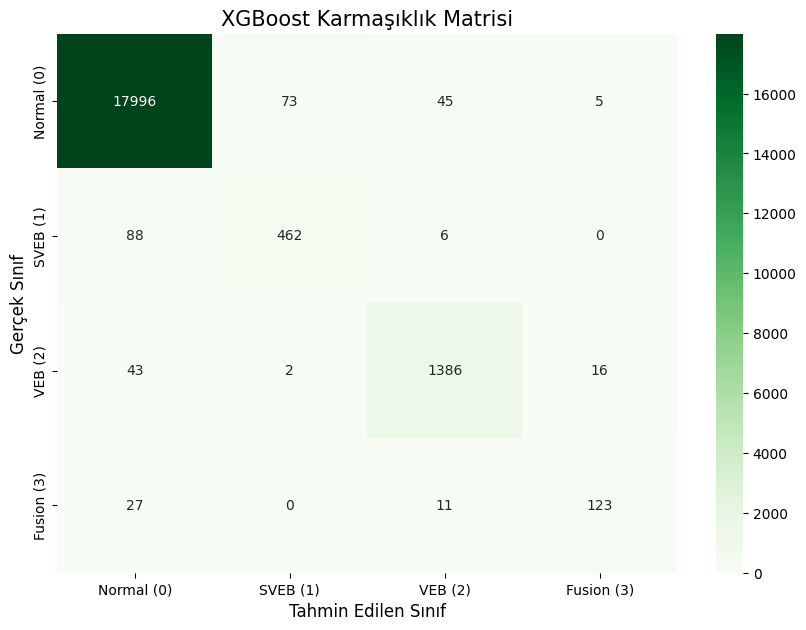

In [ ]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. VERİYİ 2 BOYUTLU HALE GETİRME (Reshaping)
# En sondaki 1 boyutunu (kanal) atarak veriyi (Örnek, 234) formatına çekiyoruz.
X_train_xgb = np.squeeze(X_train)
X_test_xgb = np.squeeze(X_test)

# 2. ÖRNEK AĞIRLIKLARINI (Sample Weights) OLUŞTURMA
# y_train içindeki her bir atışın sınıfına bakıp, class_weights_dict'teki ağırlığını yeni bir listeye yazıyoruz.
sample_weights = np.array([class_weights_dict[label] for label in y_train])

# 3. XGBOOST MODELİNİ TANIMLAMA
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',  # Çok sınıflı sınıflandırma yapacağımızı belirtiyoruz
    num_class=4,                # 4 adet sınıfımız var (0, 1, 2, 3)
    eval_metric='mlogloss',     # Hata hesaplama metriği
    random_state=42             # Sonuçların her çalışmada aynı çıkması için
)

print("XGBoost eğitimi başlıyor... (Derin öğrenmeden daha hızlı bitecektir)")

# Modeli Eğitme (Ağırlıkları sample_weight parametresi ile veriyoruz)
xgb_model.fit(X_train_xgb, y_train, sample_weight=sample_weights)

print("--- EĞİTİM TAMAMLANDI ---\n")

# 4. TAHMİN VE DEĞERLENDİRME
print("Test verisi üzerinden tahminler yapılıyor...")
y_pred_xgb = xgb_model.predict(X_test_xgb)

class_names = ['Normal (0)', 'SVEB (1)', 'VEB (2)', 'Fusion (3)']

# Sınıflandırma Raporu
print("="*50)
print("       XGBOOST SINIFLANDIRMA RAPORU")
print("="*50)
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

# Karmaşıklık Matrisi (Confusion Matrix) Çizdirme
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('XGBoost Karmaşıklık Matrisi', fontsize=15)
plt.ylabel('Gerçek Sınıf', fontsize=12)
plt.xlabel('Tahmin Edilen Sınıf', fontsize=12)
plt.show()

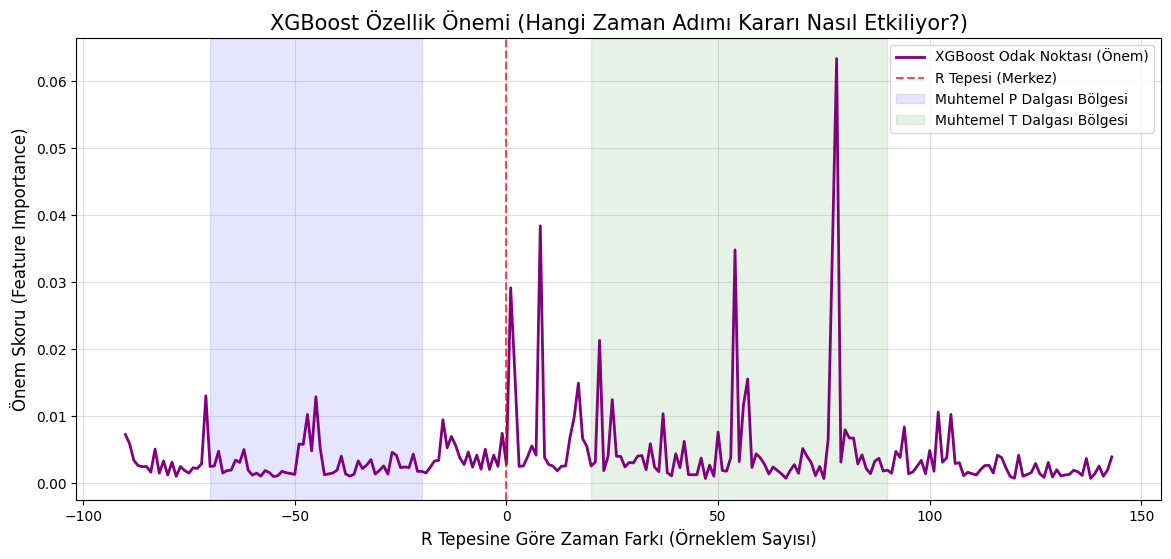

NameError: name 'top_indices' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. XGBoost modelinden özellik önem (Feature Importance) değerlerini çek
importances = xgb_model.feature_importances_

# 2. Zaman eksenini oluştur (R tepesi 0 noktasında olacak şekilde)
# Segmentasyon yaparken R öncesi 90, R sonrası 144 örneklem almıştık (Toplam 234)
time_axis = np.arange(-90, 144)

# 3. Görselleştirme
plt.figure(figsize=(14, 6))

# Önem değerlerini çizgi grafiği olarak çizdir
plt.plot(time_axis, importances, color='purple', linewidth=2, label='XGBoost Odak Noktası (Önem)')

# R tepesini (0 noktasını) belirten dikey bir çizgi çek
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='R Tepesi (Merkez)')

# Grafiğin daha okunaklı olması için P ve T dalgası tahmini bölgelerini tarayalım
plt.axvspan(-70, -20, color='blue', alpha=0.1, label='Muhtemel P Dalgası Bölgesi')
plt.axvspan(20, 90, color='green', alpha=0.1, label='Muhtemel T Dalgası Bölgesi')

plt.title("XGBoost Özellik Önemi (Hangi Zaman Adımı Kararı Nasıl Etkiliyor?)", fontsize=15)
plt.xlabel("R Tepesine Göre Zaman Farkı (Örneklem Sayısı)", fontsize=12)
plt.ylabel("Önem Skoru (Feature Importance)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.show()

# En önemli ilk 5 noktayı metin olarak da yazdıralım
top_indices